# Analysis of MPEG-DASH Adaptive Bitrate (ABR) Algorithms
In this notebook, we are analyzing the performance of three different Adaptive Bitrate (ABR) algorithms: **Throughput-based**, **BOLA**, and **Dynamic**. 

The data was collected using a dash.js (v4.7.0) media player playing a [VoD DASH playlist](http://dash.akamaized.net/dash264/TestCases/1a/sony/SNE_DASH_SD_CASE1A_REVISED.mpd). To thoroughly test how these algorithms handle changing network conditions, we applied a specific bandwidth throttling strategy using Chrome's network inspection tools during a 6-minute playback period:
* **0 - 1 minute:** No throttling
* **1 - 3 minutes:** Fast4G
* **3 - 4 minutes:** No throttling
* **4 - 6 minutes:** Fast4G

Data metrics (buffer level, measured throughput, and latency) were collected via a custom JavaScript function every 8 seconds. Our goal is to compare how each algorithm adapts to the sudden drops and recoveries in network bandwidth.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_palette("colorblind")

DATA_PATH = "data"
RESULTS_PATH = "results"

df_dynamic = pd.read_csv(f"{DATA_PATH}/Dynamic-ABR.csv")
df_bola = pd.read_csv(f"{DATA_PATH}/BOLA-ABR.csv")
df_throughput = pd.read_csv(f"{DATA_PATH}/Throughput-ABR.csv")

# Add an identifier column to each dataframe
df_dynamic["Algorithm"] = "Dynamic"
df_bola["Algorithm"] = "BOLA"
df_throughput["Algorithm"] = "Throughput-based"

# Combine them into a single dataset for easier analysis
df_all = pd.concat([df_dynamic, df_bola, df_throughput], ignore_index=True)

# Calculate Elapsed Time in seconds
# Since data was collected every 8 seconds, index * 8 gives us the exact second mark.
df_all["Elapsed_Time_s"] = df_all["index"] * 8

display(df_all.head())

,index,timestamp,bufferLevel_s,throughput_Mbps,latency_ms,Algorithm,Elapsed_Time_s
0,0,12:12:19 AM,33.39,1000.61,5.75,Dynamic,0
1,1,12:12:27 AM,30.38,1040.19,5.50,Dynamic,8
2,2,12:12:35 AM,32.34,887.58,5.00,Dynamic,16
3,3,12:12:43 AM,34.29,1016.02,5.75,Dynamic,24
4,4,12:12:51 AM,31.29,1003.12,7.50,Dynamic,32


## Handling Outliers
During the initial playback phase (unthrottled), some algorithms pull in massive amounts of data to fill the buffer, creating extreme throughput spikes that compress the rest of the graph and make it hard to read. 

To improve readability without breaking our time-series lines, we will cap (clip) these extreme outliers at the 90th percentile.

In [8]:
# Calculate the 90th percentile for throughput
throughput_cap = df_all["throughput_Mbps"].quantile(0.90)

# Clip the values so anything above the 90th percentile is capped at that limit
df_all["throughput_Mbps"] = df_all["throughput_Mbps"].clip(upper=throughput_cap)

# We can also gently cap latency if there are massive anomalies,
# using the 95th percentile to ensure we don't erase valid Fast4G spikes.
latency_cap = df_all["latency_ms"].quantile(0.95)
df_all["latency_ms"] = df_all["latency_ms"].clip(upper=latency_cap)

print(f"Capped Throughput at: {throughput_cap:.2f} Mbps")
print(f"Capped Latency at: {latency_cap:.2f} ms")

Capped Throughput at: 499.14 Mbps
Capped Latency at: 379.90 ms


## Visualizing the Throttling Strategy
To make the graphs easier to interpret, we will define a helper function to shade the background of our plots. The shaded red regions will represent the "Fast4G" throttled periods, allowing us to visually correlate the network drops with the algorithm's behavior.

In [9]:
def add_throttling_zones(ax):
    """Adds shaded regions to the plot to indicate Fast4G throttling phases."""
    # First Fast4G phase: 1 min to 3 mins (60s to 180s)
    ax.axvspan(60, 180, color="red", alpha=0.1, label="Fast4G Throttling")
    # Second Fast4G phase: 4 mins to 6 mins (240s to 360s)
    ax.axvspan(240, 360, color="red", alpha=0.1)

## 1. Measured Throughput Analysis
First, let's look at the measured throughput. This metric shows us how much bandwidth the dash.js player was actually able to utilize at any given moment. We expect to see severe drops during the Fast4G throttling phases.

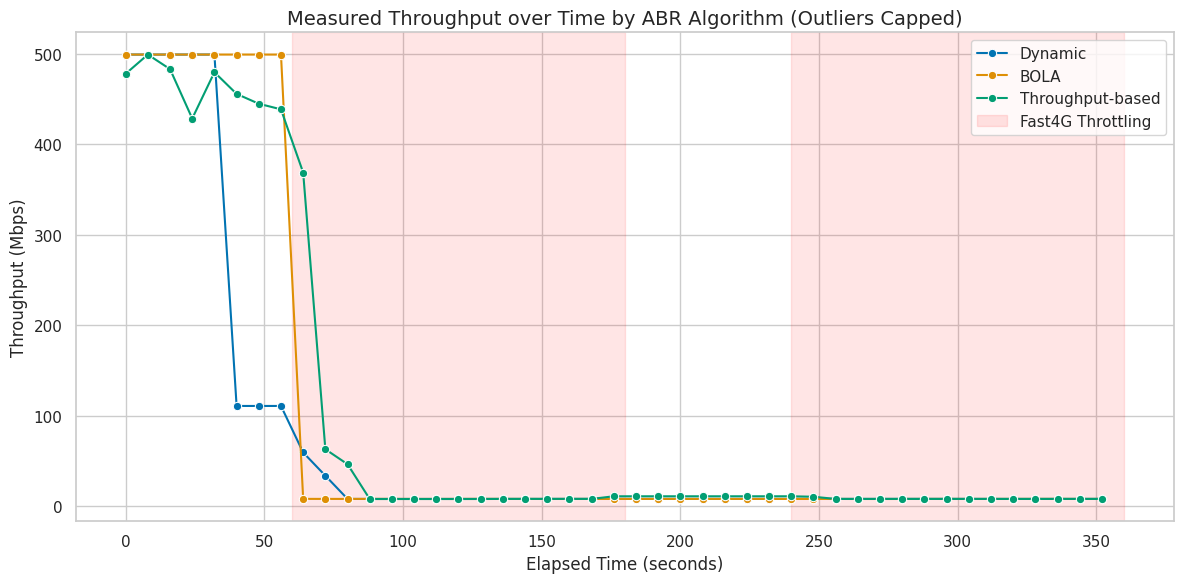

In [10]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=df_all, x="Elapsed_Time_s", y="throughput_Mbps", hue="Algorithm", marker="o")

add_throttling_zones(ax)

plt.title("Measured Throughput over Time by ABR Algorithm (Outliers Capped)", fontsize=14)
plt.xlabel("Elapsed Time (seconds)", fontsize=12)
plt.ylabel("Throughput (Mbps)", fontsize=12)
# Ensure legend handles the shaded region properly
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, loc="upper right")
plt.tight_layout()
plt.savefig(
    f"{RESULTS_PATH}/measured_throughput_over_time_by_ABR_algorithm.png",
    format="png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

### Throughput Analysis Results
In the throughput graph, there's a huge spike right at the beginning (0-60s) as the player aggressively downloads segments to build up its initial buffer. There was a small timing inconsistency with our data. The throughput for BOLA and Dynamic drops off a few seconds before our shaded Fast4G zone actually starts. This is definitely a human error on our part from trying to manually click the throttling toggle in Chrome DevTools while the collection script was running.

Interestingly, when the first Fast4G phase ends at the 3-minute mark, throughput doesn't shoot back up to those initial heights. This is actually expected behavior. Since the buffer was already full (which we'll see in the next graph), the player just goes into a maintenance mode. It grabs smaller, occasional chunks as needed to keep the buffer topped off, rather than hogging all the newly available unthrottled bandwidth.

## 2. Buffer Level Analysis
The buffer level (in seconds) is a critical metric for user experience. A buffer that drops to zero means the video stalls (rebuffering). 

- **Throughput-based** algorithms purely look at the bandwidth to pick video quality, which can sometimes lead to dangerous buffer depletion if bandwidth drops suddenly.
- **BOLA** heavily prioritizes the buffer state, keeping it as stable as possible to avoid stalls.
- **Dynamic** is a hybrid approach, using throughput estimation when the buffer is low, and switching to BOLA when the buffer is safely filled. 

Let's see how they compare during our throttling experiment.

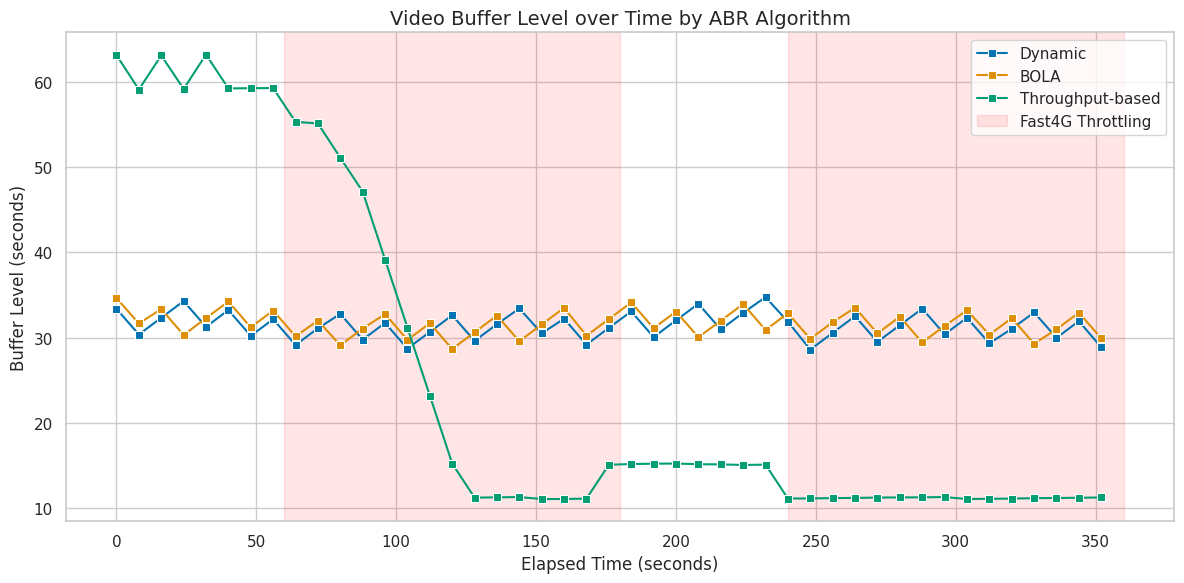

In [11]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=df_all, x="Elapsed_Time_s", y="bufferLevel_s", hue="Algorithm", marker="s")

add_throttling_zones(ax)

plt.title("Video Buffer Level over Time by ABR Algorithm", fontsize=14)
plt.xlabel("Elapsed Time (seconds)", fontsize=12)
plt.ylabel("Buffer Level (seconds)", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(
    f"{RESULTS_PATH}/video_buffer_level_over_time_by_ABR.png",
    format="png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

### Buffer Level Analysis Results
This graph clearly illustrates the core difference in algorithm design.

Both BOLA and Dynamic stayed completely stable. Even when we tanked the network to Fast4G speeds, their buffers barely moved, staying right around the 30-34 second mark. They successfully lowered the video quality to keep the buffer from emptying out.

In stark contrast, the Throughput-based algorithm struggles significantly. It starts with a massive buffer of over 60 seconds, but as soon as the first Fast4G throttling phase hits, its buffer plummets dangerously low, bottoming out around 11 seconds. Even when the network recovers between 180 and 240 seconds, it only manages a meager recovery to 15 seconds before dropping again. This perfectly highlights the risk of relying purely on bandwidth estimations: if the throughput drops suddenly, the algorithm can easily drain its buffer and risk stalling the video.

## 3. Latency Analysis
Latency in this context refers to the time it takes to request and receive the video segments (averaged over the last four requests). When bandwidth is throttled to Fast4G, segments take longer to download, so we should see spikes in latency.

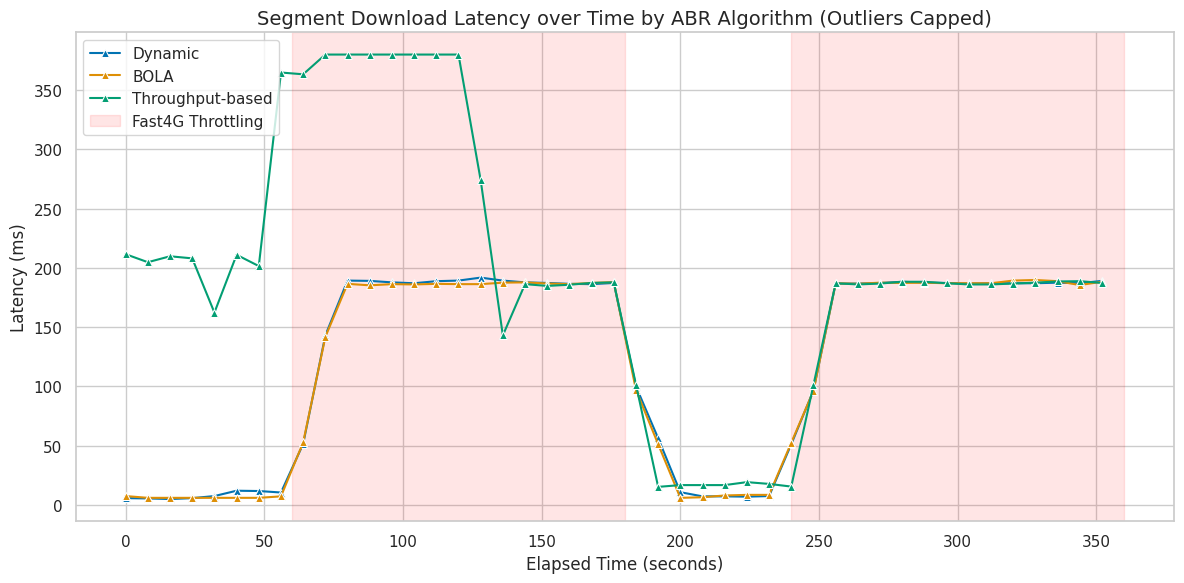

In [12]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=df_all, x="Elapsed_Time_s", y="latency_ms", hue="Algorithm", marker="^")

add_throttling_zones(ax)

plt.title("Segment Download Latency over Time by ABR Algorithm (Outliers Capped)", fontsize=14)
plt.xlabel("Elapsed Time (seconds)", fontsize=12)
plt.ylabel("Latency (ms)", fontsize=12)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(
    f"{RESULTS_PATH}/segment_download_latency_over_time_by_ABR_algorithm.png",
    format="png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

### Latency Analysis Results
The latency graph gives us the most direct look at our network conditions. For BOLA and Dynamic, it behaves exactly like we wanted. Latency is practically zero during the normal phases and jumps to around 190ms precisely during the Fast4G zones.

However, the Throughput-based run is a mess at the start. Its latency kicks off abnormally high (~200ms) right from the jump, way before we were supposed to throttle it, and hits our cap of ~380ms during the first Fast4G phase. This was almost certainly sloppy execution on our end. We probably left the Fast4G profile on by accident when starting that specific test, or some background app was downloading an update and interfering. Luckily, it leveled out and matched the other algorithms by the 180-second mark, so the second half of that run still gives us usable data.

## Discussion and Conclusion
Looking at the overall data, we can draw a few main conclusions about how these three ABR algorithms handle unstable networks:

1. **Response to Bandwidth Drops (Fast4G Phases):** The latency graphs prove our manual throttling worked (for the most part). When the bandwidth dropped, the Throughput-based algorithm reacted too slowly and let its buffer drain. BOLA and Dynamic caught the drop much better and adjusted their segment requests to avoid stalling out.

2. **Buffer Stability:** The buffer-driven approach is the clear winner here. BOLA kept a near-perfect flatline buffer of ~32 seconds no matter what we did to the network. Relying only on throughput proved super volatile and would likely result in a frustrating, buffering-heavy experience for a real user.

3. **The Hybrid Approach:** In our specific test, Dynamic acted almost exactly like BOLA. Because it had a full 60 seconds of unthrottled bandwidth to build a healthy buffer at the start, Dynamic's logic just deferred to BOLA's buffer-based rules for the rest of the video.

### Lessons Learned and Future Improvements
While the experiment proved that buffer-aware algorithms like BOLA are much safer, it mostly highlighted how flawed our manual testing setup was. The out-of-sync throughput drops and the ruined latency data in the first half of the Throughput run were entirely due to human error while clicking around in Chrome.

To improve the accuracy of future tests, we should:
- **Automate Throttling:** Instead of clicking DevTools manually, we should use a script (like Selenium) or a proper network conditioner like tc on Linux to trigger the drops at exact millisecond timestamps.
- **Isolate the Network:** Ensure no background applications are consuming bandwidth during the recordings to prevent the anomalies seen in our Throughput-based latency graph.
- **Clear Caches:** Enforce strict browser cache clearing and connection resets between every single run so that algorithms don't benefit from previously cached segments or lingering connections.